In [152]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.ticker as mticker
import numpy as np
from matplotlib.lines import Line2D
from scipy.interpolate import PchipInterpolator
from shapely.geometry import Polygon, MultiPolygon
from shapely.ops import unary_union
import tcmarkers
import cartopy.io.shapereader as shapereader
import geopandas as gpd

In [153]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'  # 關鍵：啟用 Retina 高解析度

plt.rcParams["font.family"] = ['PingFang HK'] 
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 9  # 稍微放大字體，避免小字模糊
plt.rcParams["legend.framealpha"] = 0.95
plt.rcParams["axes.titlepad"] = 15
plt.rcParams["patch.linewidth"] = 0.8

# 圖片解析度
plt.rcParams["figure.dpi"] = 150       # Jupyter 顯示解析度
plt.rcParams["savefig.dpi"] = 300      # 匯出圖片解析度（若要存檔）

#範圍
extent = [100,140,7,36]
LAT_TO_KM = 110.574
KM_TO_DEG = 1 / 111

# 配色
ERROR_CIRCLE_FILL = "#FFF8E1"
ERROR_CIRCLE_EDGE = "#FFCC80"
ERROR_CIRCLE_ALPHA = 0.4
PAST_PATH_COLOR = "#2E7D32"
FORECAST_PATH_COLOR = "#1565C0"
PATH_WIDTH = 1.8

# 粵港澳統一顏色
SPECIAL_COLOR = "#FFB74D"
SPECIAL_ALPHA = 0.6
SPECIAL_EDGE = "#E65100"

# 預報標籤透明度
LABEL_BBOX = dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7,
                 edgecolor="#CFD8DC", linewidth=0.6)
ANNOTATE_ARROW = dict(arrowstyle="-", color="#607D8B", linewidth=0.6, alpha=0.6)
MARKER_SIZE = 5
X_MARKER_SIZE = 5

In [154]:
def get_intensity_info(wind_speed, cyclone_type="tropical"):
    if cyclone_type == "EX":
        return ("溫帶氣旋", "#90A4AE", tcmarkers.HU)
    if wind_speed < 41:
        return ("低壓區", "#90A4AE", tcmarkers.HU)
    elif 41 <= wind_speed <= 62:
        return ("熱帶低氣壓", "#FFEE58", tcmarkers.HU)
    elif 63 <= wind_speed <= 87:
        return ("熱帶風暴", "#42A5F5", tcmarkers.HU)
    elif 88 <= wind_speed <= 117:
        return ("強烈熱帶風暴", "#66BB6A", tcmarkers.HU)
    elif 118 <= wind_speed <= 149:
        return ("颱風", "#FFA726", tcmarkers.HU)
    elif 150 <= wind_speed <= 184:
        return ("強颱風", "#EF5350", tcmarkers.HU)
    else:
        return ("超強颱風", "#AB47BC", tcmarkers.HU)

In [155]:
tcPathData = [
    {"lat": 16.0, "lng": 110.5, "speed": 45, "pressure": 1002, "time": "06月11日02時", "type": "past"},
    {"lat": 16.2, "lng": 110.8, "speed": 45, "pressure": 1002, "time": "06月11日05時", "type": "past"},
    {"lat": 16.5, "lng": 111.2, "speed": 55, "pressure": 1000, "time": "06月11日08時", "type": "past"},
    {"lat": 16.8, "lng": 111.8, "speed": 55, "pressure": 1000, "time": "06月11日11時", "type": "past"},
    {"lat": 16.0, "lng": 112.5, "speed": 65, "pressure": 998, "time": "06月11日14時", "type": "past"},
    {"lat": 16.0, "lng": 112.2, "speed": 65, "pressure": 998, "time": "06月11日17時", "type": "current"},
    #------------------------------------------------------------------------------------------------------------------
    {"lat": 17.0, "lng": 113.0, "speed": 65, "pressure": 998, "time": "06月12日05時", "type": "forecast", "hours": 12},
    {"lat": 17.0, "lng": 114.5, "speed": 75, "pressure": 995, "time": "06月12日17時", "type": "forecast", "hours": 24},
    {"lat": 18.0, "lng": 115.5, "speed": 85, "pressure": 990, "time": "06月13日05時", "type": "forecast", "hours": 36},
    {"lat": 19.5, "lng": 116.5, "speed": 90, "pressure": 985, "time": "06月13日17時", "type": "forecast", "hours": 48},
    {"lat": 20.3, "lng": 117.5, "speed": 110, "pressure": 980, "time": "06月14日05時", "type": "forecast", "hours": 60},
    {"lat": 21.5, "lng": 118.0, "speed": 120, "pressure": 975, "time": "06月14日17時", "type": "forecast", "hours": 72},
    {"lat": 22.5, "lng": 119.6, "speed": 110, "pressure": 978, "time": "06月15日17時", "type": "forecast", "hours": 96},
    {"lat": 26.0, "lng": 121.6, "speed": 85, "pressure": 988, "time": "06月16日17時", "type": "forecast", "hours": 120},
]

In [156]:
past_data = [[item["time"], item["lng"], item["lat"], item["speed"], item["pressure"]] 
             for item in tcPathData if item["type"] in ["past", "current"]]
forecast_data = []
for item in tcPathData:
    if item["type"] == "forecast":
        if "cyclone_type" in item:
            forecast_data.append([item["time"], item["lng"], item["lat"], item["speed"], item["hours"], item["cyclone_type"]])
        else:
            forecast_data.append([item["time"], item["lng"], item["lat"], item["speed"], item["hours"]])

def hours_to_error(hours):
    return (hours // 24) * 100 + (hours % 24) * (100 / 24)

current_data = past_data[-1]
if len(current_data) == 6:
    current_time, current_lon, current_lat, current_wind, current_press, current_cyclone_type = current_data
else:
    current_time, current_lon, current_lat, current_wind, current_press = current_data
    current_cyclone_type = "tropical"
current_intensity, current_color, current_marker = get_intensity_info(current_wind, current_cyclone_type)

In [157]:
plt.close('all')

fig, ax = plt.subplots(figsize=(8, 7), subplot_kw={'projection': ccrs.PlateCarree()}, facecolor="#FAFAFA")
ax.set_extent(extent, crs=ccrs.PlateCarree())

# 底圖：柔和陸海色
ax.add_feature(cfeature.LAND, color="#F5F5F5", alpha=0.9)
ax.add_feature(cfeature.OCEAN, color="#E3F2FD", alpha=0.9)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, color="#424242")
ax.add_feature(cfeature.BORDERS, linewidth=0.7, color="#757575")

# 粵港澳地區

shpfilename = shapereader.natural_earth(resolution='10m', category='cultural', name='admin_1_states_provinces')
reader = shapereader.Reader(shpfilename)
for rec in reader.records():
    # Use lowercase for safer matching
    name_val = rec.attributes.get('name_en', '').lower()
    
    # Check if 'guangdong', 'hong kong', or 'maca' is in the name
    # (using 'maca' catches both Macao and Macau)
    targets = ['guangdong', 'hong kong', 'maca']
    
    if any(t in name_val for t in targets):
        ax.add_geometries([rec.geometry], ccrs.PlateCarree(),
                          facecolor=SPECIAL_COLOR, edgecolor=SPECIAL_EDGE,
                          linewidth=1.0, alpha=SPECIAL_ALPHA, zorder=2)
# Load shapefile (replace with your file path)

# 省界線
province_borders = cfeature.NaturalEarthFeature(
    category='cultural', name='admin_1_states_provinces_lines', scale='10m', facecolor='none')
ax.add_feature(province_borders, edgecolor="#90A4AE", linewidth=0.5, linestyle=":", alpha=0.7)

# 網格線
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.4, color="#CFD8DC", alpha=0.7, linestyle="-")
gl.top_labels = False
gl.right_labels = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {"size": 5, "color": "#546E7A"}
gl.ylabel_style = {"size": 5, "color": "#546E7A"}

# 過去路徑
prev_past_lon, prev_past_lat = None, None
for i, data in enumerate(past_data):
    time, lon, lat, wind, press = data[:5]
    if prev_past_lon is not None and prev_past_lat is not None:
        ax.plot([prev_past_lon, lon], [prev_past_lat, lat],
                color=PAST_PATH_COLOR, linewidth=PATH_WIDTH, transform=ccrs.PlateCarree(), zorder=3)
    prev_past_lon, prev_past_lat = lon, lat

# 當前位置
ax.plot(current_lon, current_lat,
        marker=current_marker, markersize=MARKER_SIZE,
        color=current_color, markeredgecolor="black", markeredgewidth=0.9,
        transform=ccrs.PlateCarree(), zorder=6)
ax.annotate(current_time, xy=(current_lon, current_lat),
            xytext=(current_lon + 0.8, current_lat - 0.5),
            bbox=LABEL_BBOX, arrowprops=ANNOTATE_ARROW,
            fontsize=7, color="#263238", alpha=0.7, transform=ccrs.PlateCarree(), zorder=7)

# 預報路徑 + 誤差帶
forecast_lons = [d[1] for d in forecast_data]
forecast_lats = [d[2] for d in forecast_data]
forecast_hours = [d[4] for d in forecast_data]
forecast_errors_km = [hours_to_error(h) for h in forecast_hours]
forecast_error_deg = [err * KM_TO_DEG for err in forecast_errors_km]

all_hours = [0] + forecast_hours
all_lons = [current_lon] + forecast_lons
all_lats = [current_lat] + forecast_lats
all_errors = [0] + forecast_error_deg

points_num = 25
interp_hours = []
for i in range(len(all_hours)-1):
    segment = np.linspace(all_hours[i], all_hours[i+1], points_num)[:-1]
    interp_hours.extend(segment)
interp_hours.append(all_hours[-1])
interp_hours = np.array(interp_hours)

x = PchipInterpolator(all_hours, all_lons)(interp_hours)
y = PchipInterpolator(all_hours, all_lats)(interp_hours)
r = PchipInterpolator(all_hours, all_errors)(interp_hours)

thetas = np.linspace(0, 2*np.pi, 360)
polygon_x = x[:, None] + r[:, None] * np.cos(thetas)
polygon_y = y[:, None] + r[:, None] * np.sin(thetas)
ps = [Polygon(p) for p in np.dstack((polygon_x, polygon_y))]
polys = unary_union([MultiPolygon([ps[i], ps[i+1]]).convex_hull for i in range(len(ps)-1)])

ax.add_geometries([polys], ccrs.PlateCarree(),
                  facecolor=ERROR_CIRCLE_FILL, alpha=ERROR_CIRCLE_ALPHA,
                  edgecolor=ERROR_CIRCLE_EDGE, linewidth=0.9, zorder=4)
ax.plot(x, y, color=FORECAST_PATH_COLOR, linewidth=PATH_WIDTH,
        linestyle="--", transform=ccrs.PlateCarree(), zorder=5)

# 預報節點
MAJOR_HOURS = {24,48,72,96,120}
for i, data in enumerate(forecast_data):
    time, lon, lat, wind, hours = data[:5]
    ctype = data[5] if len(data)>5 else 'tropical'
    inten, col, mark = get_intensity_info(wind, ctype)
    if hours in MAJOR_HOURS:
        ax.plot(lon, lat, marker=mark, markersize=MARKER_SIZE,
                color=col, markeredgecolor="#263238", markeredgewidth=0.7,
                transform=ccrs.PlateCarree(), zorder=5)
        ax.annotate(time, xy=(lon, lat), xytext=(lon+0.5, lat-0.3),
                    bbox=LABEL_BBOX, arrowprops=ANNOTATE_ARROW,
                    fontsize=6.5, color="#263238", alpha=0.7, transform=ccrs.PlateCarree(), zorder=7)
    else:
        ax.plot(lon, lat, marker="x", markersize=X_MARKER_SIZE,
                color=FORECAST_PATH_COLOR, markeredgewidth=1.3,
                transform=ccrs.PlateCarree(), zorder=5, alpha=0.8)

# 現時位置資訊框：精簡
current_label_text = (f"現時位置資料\n"
                     f"時間：{current_time}\n"
                     f"強度：{current_intensity}\n"
                     f"近中心最大風速：{current_wind} kph　中心氣壓：{current_press} hPa\n"
                     f"位置：{current_lat:.1f}°N {current_lon:.1f}°E")
ax.text(0.02, 0.95, current_label_text, transform=ax.transAxes,
        fontsize=8, va="top",
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#CFD8DC", alpha=0.98),
        zorder=10, color="#263238", linespacing=1.3)

/opt/anaconda3/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/opt/anaconda3/lib/python3.11/site-packages/shapely/set_operations.py:421: RuntimeWarning: invalid value encountered in unary_union
  return lib.unary_union(collections, **kwargs)


Text(0.02, 0.95, '現時位置資料\n時間：06月11日17時\n強度：熱帶風暴\n近中心最大風速：65 kph\u3000中心氣壓：998 hPa\n位置：16.0°N 112.2°E')

/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


In [158]:
legend_path = [
    Line2D([0],[0], color=PAST_PATH_COLOR, lw=PATH_WIDTH, label="過去路徑"),
    Line2D([0],[0], color=FORECAST_PATH_COLOR, lw=PATH_WIDTH, ls="--", label="預報路徑"),
    plt.Rectangle((0,0),1,1, fc=ERROR_CIRCLE_FILL, alpha=ERROR_CIRCLE_ALPHA,
                  edgecolor=ERROR_CIRCLE_EDGE, label="誤差帶"),
    plt.Rectangle((0,0),1,1, fc=SPECIAL_COLOR, alpha=SPECIAL_ALPHA,
                  edgecolor=SPECIAL_EDGE, label="粵港澳地區"),
]
leg1 = ax.legend(handles=legend_path, loc="lower center", bbox_to_anchor=(0.5, -0.12),
                 ncol=4, fontsize=8, frameon=True, fancybox=True, facecolor="white", edgecolor="#E0E0E0")
ax.add_artist(leg1)

legend_intensity = [
    Line2D([0],[0], marker=tcmarkers.HU, color="#90A4AE", linestyle="None", markersize=5, label="低壓區"),
    Line2D([0],[0], marker=tcmarkers.HU, color="#FFEE58", linestyle="None", markersize=5, label="熱帶低氣壓"),
    Line2D([0],[0], marker=tcmarkers.HU, color="#42A5F5", linestyle="None", markersize=5, label="熱帶風暴"),
    Line2D([0],[0], marker=tcmarkers.HU, color="#66BB6A", linestyle="None", markersize=5, label="強烈熱帶風暴"),
    Line2D([0],[0], marker=tcmarkers.HU, color="#FFA726", linestyle="None", markersize=5, label="颱風"),
    Line2D([0],[0], marker=tcmarkers.HU, color="#EF5350", linestyle="None", markersize=5, label="強颱風"),
    Line2D([0],[0], marker=tcmarkers.HU, color="#AB47BC", linestyle="None", markersize=5, label="超強颱風")
]
ax.legend(handles=legend_intensity, loc="lower center", bbox_to_anchor=(0.5, -0.22),
          ncol=4, fontsize=8, frameon=True, fancybox=True, facecolor="white", edgecolor="#E0E0E0")

/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


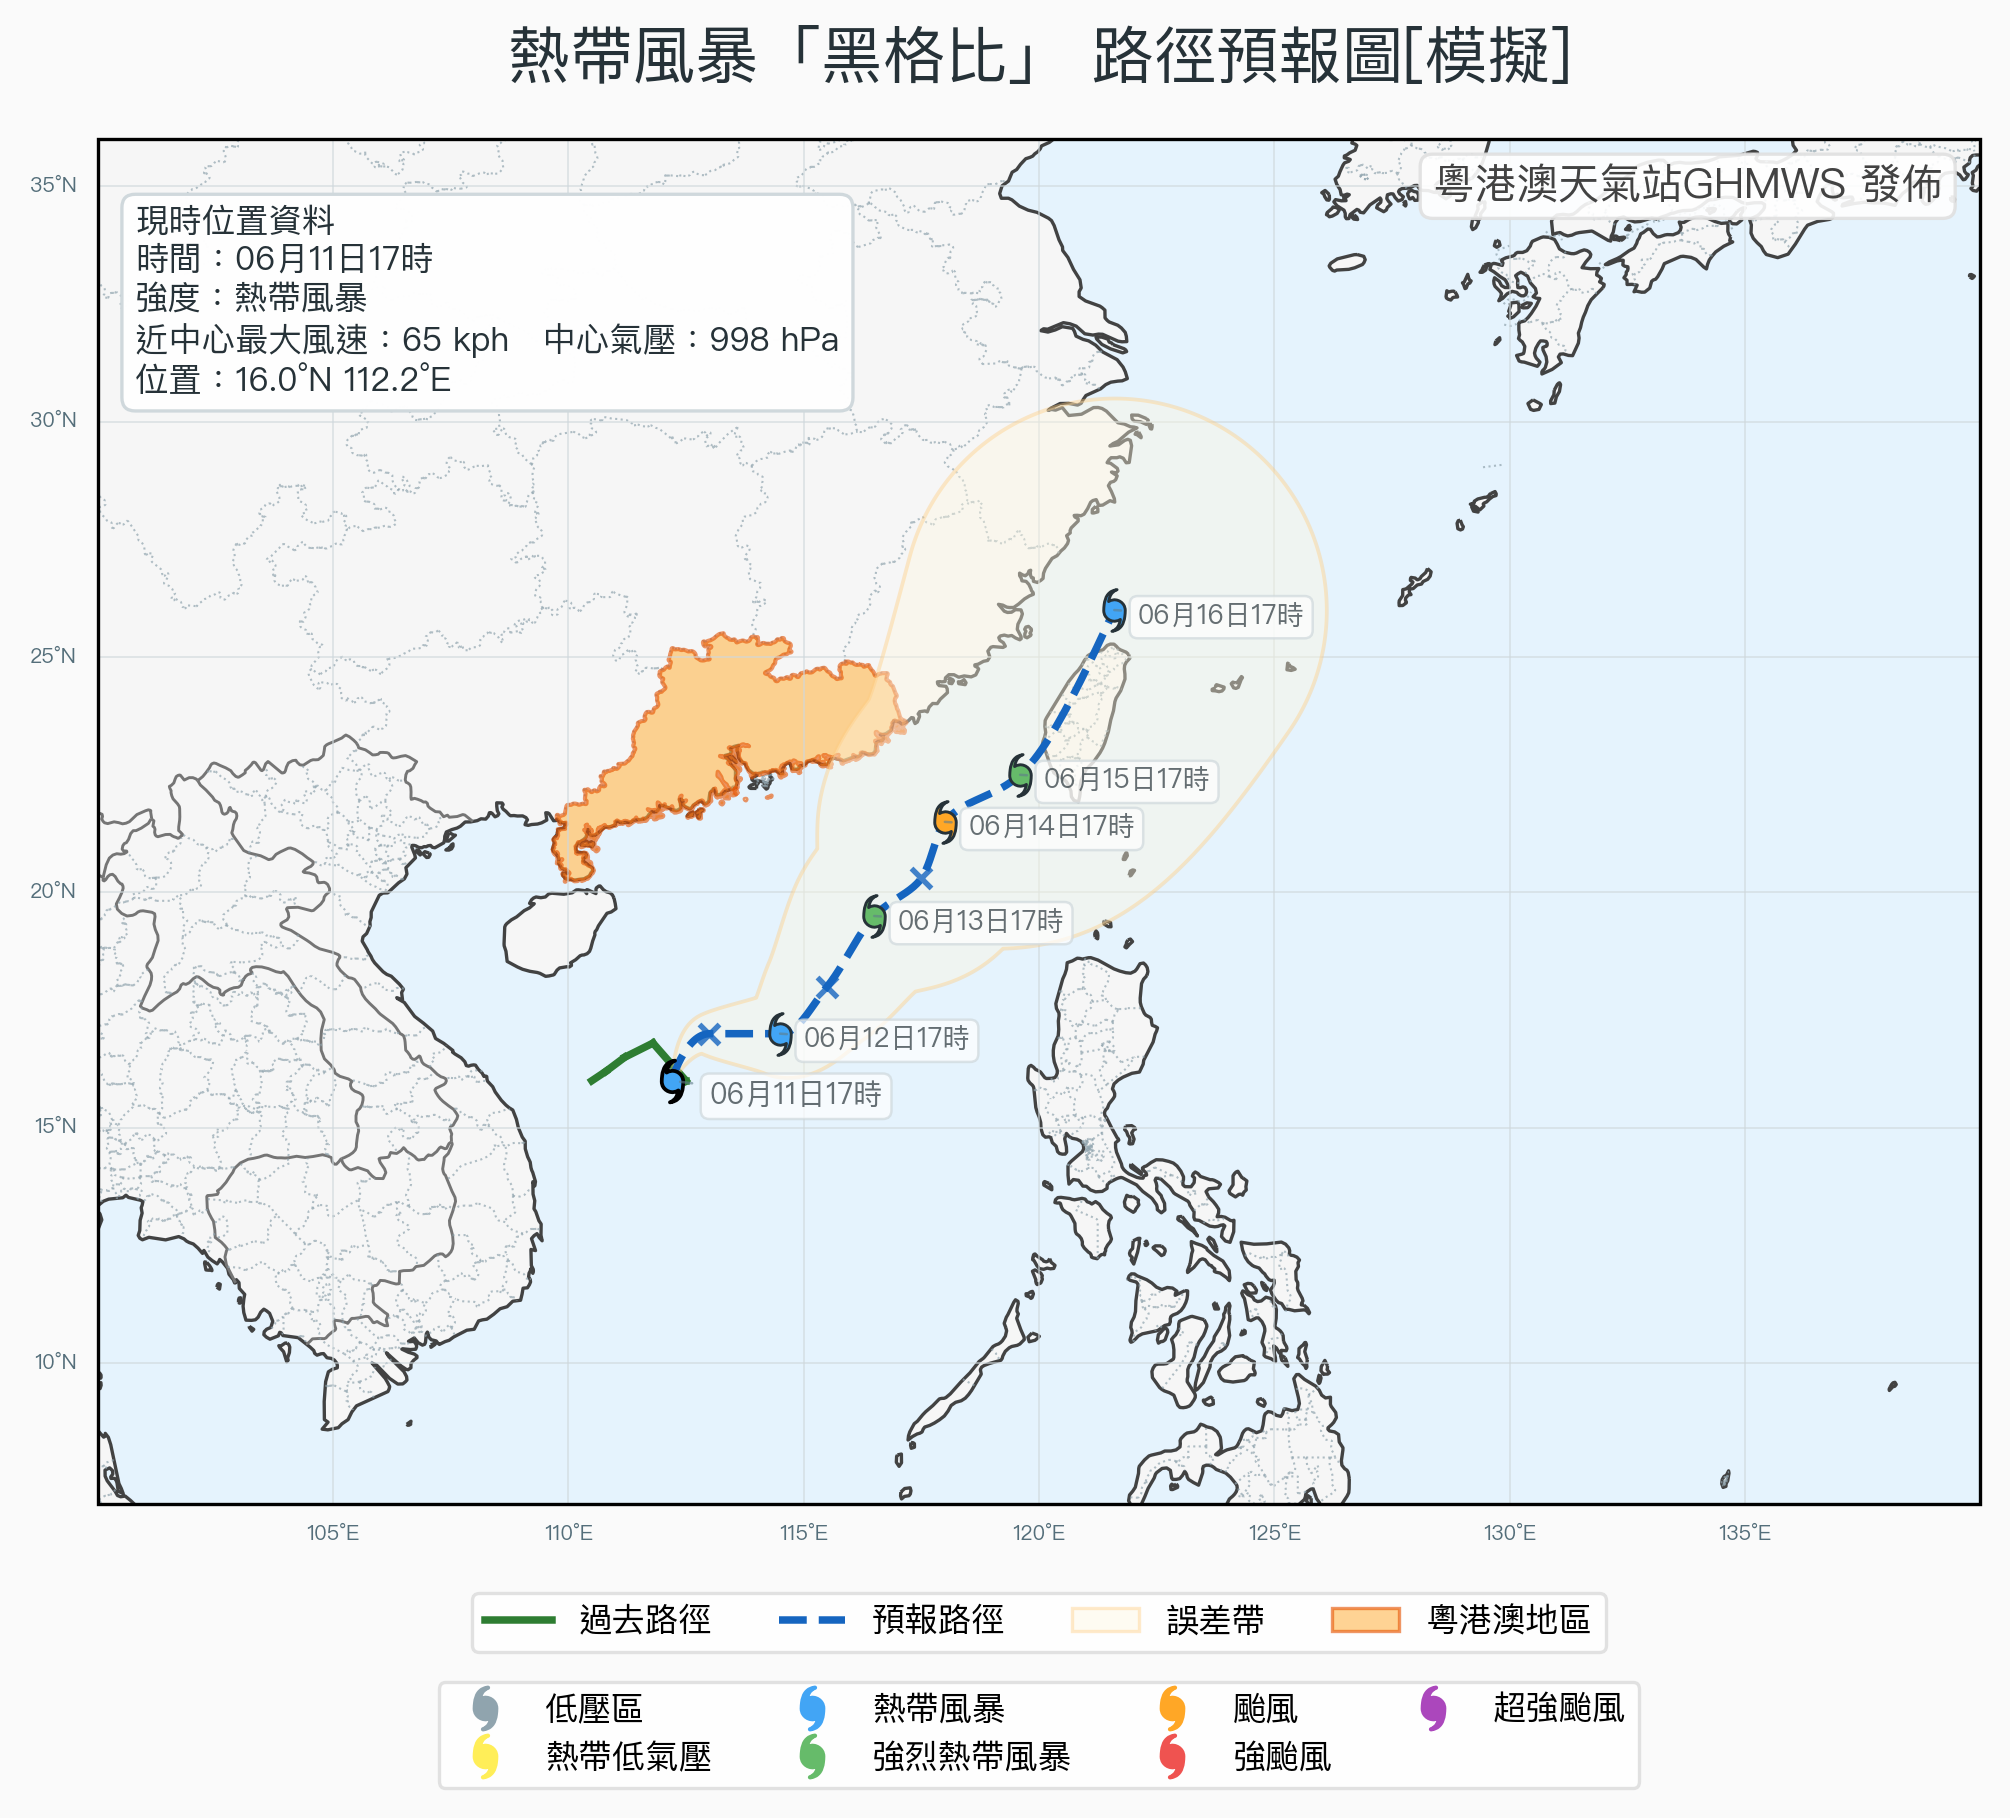

In [159]:
# ----------------------------
# 標題 + 發佈資訊
# ----------------------------
plt.title("熱帶風暴「黑格比」 路徑預報圖[模擬]",
          fontsize=15, pad=15, fontweight="bold", color="#263238")
ax.text(0.98, 0.98, "粵港澳天氣站GHMWS 發佈",
        horizontalalignment="right", verticalalignment="top",
        transform=ax.transAxes, fontsize=10, color="#424242",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9, edgecolor="#E0E0E0"))

plt.tight_layout()
plt.subplots_adjust(left=0.03, right=0.97, bottom=0.28, top=0.93)

display(fig)
plt.close(fig)

ValueError: Axes should be an instance of GeoAxes, got <class 'matplotlib.axes._axes.Axes'>

<Figure size 960x720 with 1 Axes>